## Bidirectional LSTM in NLP


Bidirectional Long Short-Term Memory (BiLSTM) is an extension of traditional LSTM network. Unlike conventional Long Short-Term Memory (LSTM) that process sequences in only one direction, BiLSTMs allow information to flow from both forward and backward enabling them to capture more contextual information. This makes BiLSTMs particularly effective for tasks where understanding both past and future context is crucial.

### Understanding Bidirectional LSTM (BiLSTM)

A Bidirectional LSTM (BiLSTM) consists of two separate LSTM layers:

* **Forward LSTM:** Processes the sequence from start to end
* **Backward LSTM:** Processes the sequence from end to start
The outputs of both LSTMs are then combined to form the final output. Mathematically, the final output at time t is computed as:

$$h_t = [\overrightarrow{h_t}; \overleftarrow{h_t}]
$$  
Where $\overrightarrow{h_t}$ is the output from the forward LSTM and $\overleftarrow{h_t}$ is the output from the backward LSTM.

The following diagram represents the BiLSTM layer:

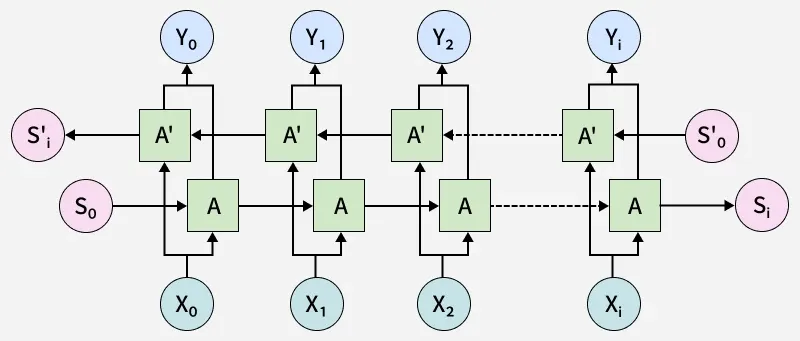


## Implementation: Sentiment Analysis Using BiLSTM


### 1. Importing Libraries

We will be using python libraries like numpy, pandas , matplotlib and tensorflow libraries for building our model.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

### 2. Loading and Preparing the IMDB Dataset
We will load IMDB dataset from tensorflow which contains 25,000 labeled movie reviews for training and testing. Shuffling ensures that the model does not learn patterns based on the order of reviews.

In [2]:
dataset =  tfds.load('imdb_reviews', as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

batch_size = 64

train_dataset = train_dataset.shuffle(10000).batch(batch_size)
test_dataset = test_dataset.batch(batch_size)

In [3]:
example, label = next(iter(train_dataset))
print("Text: ", example[0].numpy())
print("Label: ", label[0].numpy())

Text:  b'As a another reviewer states Hanna\'s War is an outstanding film about an outstanding person, Hanna "Anniko" Senesh, who would become the Jewish Joan Of Arc. Unfortunately I diverge in opinion not agreeing that Miss Detmers as the lead is too beautiful to be taken seriously as a resistance fighter. In truth for me her performance is not held back by her beauty but makes it all the more stark in the terror of the sadistic brutality as a resistor she faces. Maruschka Detmers performance is brave, poignant, heartfelt or understood, and totally believable. In other words for me "In the zone." from the opening credits. If you would like to learn about the suffering of someone else for something they believe in and be impressively entertained give Hanna\'s War with Maruschka Detmers a try. My hat is off also to Ellen Burstyn as Hanna\'s mother a much well known and famous actress who could have made effort to walk off with the film. In that it is a team effort perhaps of two actress

### 3. Performing Text Vectorization

We will first perform text vectorization and let the encoder map all the words in the training dataset to a token. We can also see in the example below how we can encode and decode the sample review into a vector of integers.



In [4]:
vectorize_layer = tf.keras.layers.TextVectorization(
    output_mode = 'int', output_sequence_length = 1000)

vectorize_layer.adapt(train_dataset.map(lambda x, y: x))

### 4. Defining Model Architecture (BiLSTM Layers)

We will define a sequential model with an embedding layer followed by a bidirectional LSTM layer and a dense output layer. The embedding layer converts the integer tokens into dense vectors of fixed size, while the BiLSTM layer captures contextual information from both directions.

The Bidirectional LSTM layers process these sequences from both directions to capture context:

* The first Bidirectional LSTM has 32 units and outputs sequences.
* A dropout layer with rate 0.4 helps prevent overfitting.
* The second Bidirectional LSTM has 16 units and refines the learned features.
* Another dropout layer with rate 0.4 follows.

In [5]:
model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(
        len(vectorize_layer.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.build(input_shape=(None,))


model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 1000)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 1000, 64)       │     7,801,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1000, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,912,705 (30.18 MB)

 Trainable params: 7,912,705 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Training the Model

In [ ]:
history = model.fit(
    train_dataset,
    epochs=3,
    validation_data=test_dataset,
)

Epoch 1/3
 21/391 ━━━━━━━━━━━━━━━━━━━━ 31:21 5s/step - accuracy: 0.4854 - loss: 0.6929

* The model learns well on training data reaching 95.92% accuracy but struggles with validation data staying around 78%.
* The increasing validation loss shows overfitting meaning the model remembers training data but doesn't generalize well.
* To fix this we can use L2 regularization, early stopping or simplify the model to improve real-world performance.

### 6. Prediction


In [ ]:
review = tf.constant(["This movie was amazing and engaging"])
prob = tf.sigmoid(model.predict(review))[0][0]

sentiment = "Positive" if prob >= 0.5 else "Negative"
print(f"Sentiment: {sentiment}, Probability: {prob:.2f}")

                                    LSTM - Derivation of Back propagation through time                                  


## LSTM - Derivation of Back propagation through time


Long Short-Term Memory (LSTM) are a type of neural network designed to handle long-term dependencies by handling the vanishing gradient problem. One of the fundamental techniques used to train LSTMs is Backpropagation Through Time (BPTT) where we have sequential data. In this article we see how BPTT works in LSTMs.

### Why Backpropagation Through Time?

Backpropagation is the main method used to train neural networks. It helps the network learn by adjusting its weights based on how much the predictions differ from the actual values. In feedforward neural networks this process is simple because the data moves in one direction from input to output.

However in RNNs and LSTMs the situation is a bit different as they process sequential data like sentences, time-series or speech meaning that each piece of data depends on previous pieces. This creates a temporal dependency between the steps. Because of this we can't just apply backpropagation normally. Instead we need to modify it so that it can account for time dimension, this is where Backpropagation Through Time (BPTT) comes in.

It works by unfolding the algorithm over time by treating each step as a layer in a deep network. It calculates the gradients at each step and sends them backward to update the model's weights. This helps the network learn how each step in the sequence depends on the others.

LSTMs introduce structural differences that modify the gradient computations:

* LSTMs have gates (input, forget and output) that control gradient flow unlike simple RNNs.
* The cell state (0ct) enables long-term memory retention and mitigates the vanishing gradient problem.
* Unlike RNNs gradients propagate through both hidden states (ht) and cell states (ct) leading to additional partial derivatives.
* LSTMs require different gradient computations due to element-wise multiplications and activation functions.

Understanding these differences is important to know how LSTMs solve vanishing gradient issues while maintaining long-term dependencies.

### Notations Used:
* $x_t$: Input at time step t
* $h_t$: Hidden state at time step t
* $c_t$: Cell state at time step t
* $W$: Weight matrices for input, hidden state and cell state
* $b$: Bias terms
* $\sigma$: Sigmoid activation function
* $\tanh$: Hyperbolic tangent activation function

The inittial value of c0 and h0 are usually set to zero.



## Working of BPTT

### 1. Initialization of Weights

Each LSTM cell has three gates: Input Gate, Forget Gate and Output Gate each with associated weights and biases.

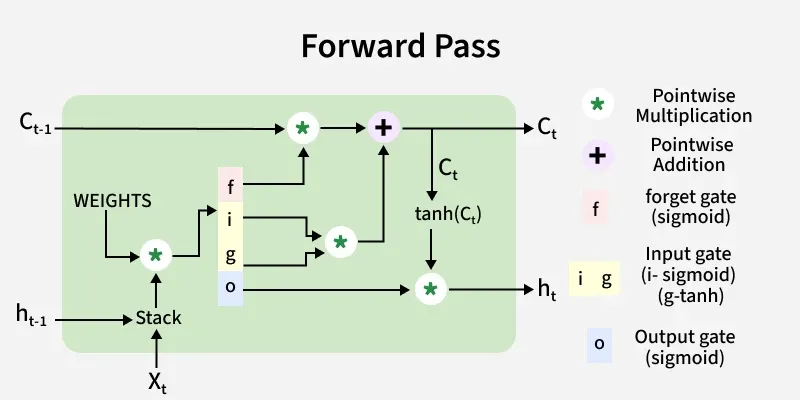

### 2. Forward Pass Through LSTM Gates

During the forward pass the input at each time step is processed through the gates to compute the hidden state and cell state. The computations are as follows:
* Forget Gate: $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
* Input Gate: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
* Candidate Cell State: $\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$
* Cell State Update: $c_t = f_t \cdot c_{t-1} + i_t \cdot \tilde{c}_t$
* Output Gate: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
* Hidden State Update: $h_t = o_t \cdot \tanh(c_t)$ 

### 3. Performing Backpropagation Through Time (BPTT) in LSTMs

The goal is to compute gradients for all weights using the chain rule considering LSTM-specific gates and memory cells.

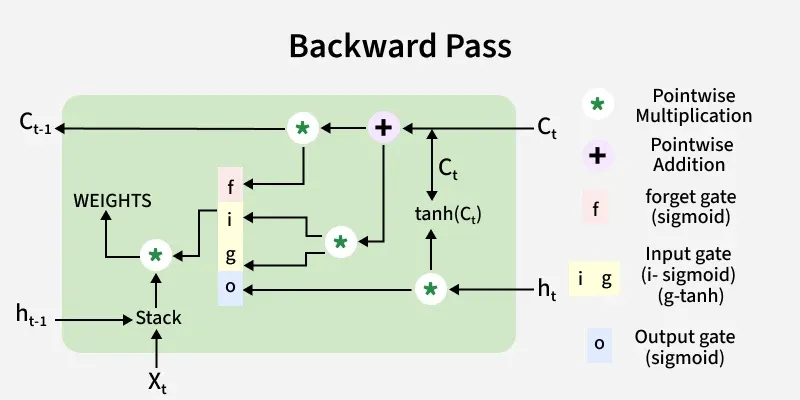

**1. Gradient of Loss w.r.t Output Gate:**

$$\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \cdot \tanh(c_t)$$
**2. Gradient of Loss w.r.t Cell State:**
$$\frac{\partial L}{\partial c_t} = \frac{\partial L}{\partial h_t} \cdot o_t \cdot (1 - \tanh^2(c_t)) + \frac{\partial L}{\partial c_{t+1}} \cdot f_{t+1}$$
**3. Gradient of Loss w.r.t Input Gate:**
$$\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial c_t} \cdot \tilde{c}_t$$
**4. Gradient of Loss w.r.t Candidate Cell State:**
$$\frac{\partial L}{\partial \tilde{c}_t} = \frac{\partial L}{\partial c_t} \cdot i_t$$
**5. Gradient of Loss w.r.t Forget Gate:**
$$\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial c_t} \cdot c_{t-1}$$
**6. Gradient of Loss w.r.t Weights and Biases:**
$$\frac{\partial L}{\partial W_f} = \frac{\partial L}{\partial f_t} \cdot [h_{t-1}, x_t]^T$$
$$\frac{\partial L}{\partial L}{\partial W_i} = \frac{\partial L}{\partial i_t} \cdot [h_{t-1}, x_t]^T$$
$$\frac{\partial L}{\partial W_c} = \frac{\partial L}{\partial \tilde{c}_t} \cdot [h_{t-1}, x_t]^T$$
$$\frac{\partial L}{\partial W_o} = \frac{\partial L}{\partial o_t} \cdot [h_{t-1}, x_t]^T$$
$$\frac{\partial L}{\partial b_f} = \frac{\partial L}{\partial f_t}$$
$$\frac{\partial L}{\partial b_i} = \frac{\partial L}{\partial i_t}$$
$$\frac{\partial L}{\partial b_c} = \frac{\partial L}{\partial \tilde{c}_t}$$
$$\frac{\partial L}{\partial b_o} = \frac{\partial L}{\partial o_t}$$


Similarly, gradients for other gates' weights and biases are calculated. Backpropagation Through Time for LSTMs involves:

Unfolding the LSTM over all timesteps.
* Calculating gradients for each gate and cell state using chain rule.
* Accounting for both hidden state and cell state dependencies.
* Propagating gradients backward through time to update weights.
* This process enables LSTMs to learn long-term dependencies in sequential data by efficiently updating weights while mitigating vanishing gradients.
